# Load Runtime Model and Checkpoints

This notebook loads the runtime transformer model and checkpoints, similar to `Inspect_Model_Outputs.ipynb` but without XGBoost components.


In [ ]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1
import os, math, torch, glob, pickle, gzip, random, yaml, json
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import pchip_interpolate
from dataclasses import dataclass
from typing import List, Tuple
from pathlib import Path

print("✅ Imports successful. torch version:", torch.__version__)


env: PYTORCH_ENABLE_MPS_FALLBACK=1
✅ Imports successful. torch version: 2.8.0
✅ Constants and file paths configured.


### Define Data Classes and Model Architecture

In [11]:
# --- 0. DATA CLASSES ---
@dataclass
class TrainingExample:
    unpadded_example_sequence: List[str]
    actual_pace_seconds: float
    raw_pace_data: List[Tuple[str, str, int]]

@dataclass
class RunnerForTraining:
    name_gender_dedup_int: Tuple[str, str, str, int]
    training_examples: List[TrainingExample]
    split_assignment: int

# --- 1. MODEL ARCHITECTURE ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class RunTimeTransformer(nn.Module):
    def __init__(self, vocab_size, num_pace_bins, config):
        super().__init__()
        m = config['model']
        self.d_model = m['d_model']
        self.embedding = nn.Embedding(vocab_size, self.d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(self.d_model, m['max_seq_length'])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=m['nhead'], 
            dim_feedforward=m['dim_feedforward'], 
            dropout=m['dropout'], 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=m['num_layers'])
        self.transformer.enable_nested_tensor = False
        self.output_head = nn.Linear(self.d_model, num_pace_bins)
        self._init_weights()
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)
        nn.init.constant_(self.output_head.bias, 0)
    def forward(self, x, padding_mask):
        sz = x.size(1)
        causal_mask = torch.triu(torch.ones(sz, sz), diagonal=1).bool().to(x.device)
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.transformer(x, mask=causal_mask, src_key_padding_mask=padding_mask)
        valid_lens = (~padding_mask).sum(dim=1) - 1
        return self.output_head(x[torch.arange(x.size(0)), valid_lens])

print("✅ Architecture defined.")


✅ Architecture defined.


### Load Model Checkpoint and Configuration

In [12]:
# --- 2. SETTINGS & CONSTANTS ---
# Same paths as Inspect_Model_Outputs.ipynb
CHECKPOINT_PATH = "/Users/yaelelmatad/Desktop/nyrr-transform/Production_Scale_v2_HighCap/best_model.pt"
CONFIG_PATH = "/Users/yaelelmatad/Desktop/nyrr-transform/Production_Scale_v2_HighCap/config_copy.yaml"
PACE_LOOKUP_PATH = "/Users/yaelelmatad/Desktop/nyrr-transform/Runtime/data/pace_lookup.pickle"
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

DISTANCE_MAP = {
    'distance_name_token_1_mile': 1.0, 'distance_name_token_1POINT5_miles': 1.5,
    'distance_name_token_3_miles': 3.0, 'distance_name_token_3_kilometers': 1.86411,
    'distance_name_token_5_kilometers': 3.10686, 'distance_name_token_4_miles': 4.0,
    'distance_name_token_5_miles': 5.0, 'distance_name_token_8_kilometers': 4.97097,
    'distance_name_token_10_kilometers': 6.21371, 'distance_name_token_12_kilometers': 7.45645,
    'distance_name_token_15_kilometers': 9.32057, 'distance_name_token_10_miles': 10.0,
    'distance_name_token_18_miles': 18.0, 'distance_name_token_20_kilometers': 12.4274,
    'distance_name_token_25_kilometers': 15.5343, 'distance_name_token_30_kilometers': 18.6411,
    'distance_name_token_half_marathon': 13.1094, 'distance_name_token_marathon': 26.2188
}

# Initialize variables
VOCAB = {}
pace_lookup = {}
pace_bins = []
MAX_LEN = 329
IS_SWAPPED = False
CONFIG = {}

print(f"Loading resources...")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Config: {CONFIG_PATH}")
print(f"Pace lookup: {PACE_LOOKUP_PATH}")
print(f"Device: {DEVICE}")
print()

try:
    # Load checkpoint
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    VOCAB = checkpoint.get('vocab', {})
    STATE_DICT = checkpoint.get('model_state_dict')
    print(f"✅ Checkpoint loaded. Vocab size: {len(VOCAB)}")
    
    # Load pace lookup
    with open(PACE_LOOKUP_PATH, 'rb') as f: 
        pace_lookup = pickle.load(f)
    
    # Build pace bins from lookup
    bins = []
    for token, info in pace_lookup.items():
        if not isinstance(info, dict): continue
        med = info.get('median_pace') or info.get('median', 0)
        bins.append({'token': token, 'start': float(info['start']), 'end': float(info['end']), 'median': float(med)})
    pace_bins = sorted(bins, key=lambda x: x['median'])
    print(f"✅ Pace lookup loaded. Number of pace bins: {len(pace_bins)}")
    
    # Load config
    with open(CONFIG_PATH, 'r') as f: 
        CONFIG = yaml.safe_load(f)
    MAX_LEN = CONFIG['model']['max_seq_length']
    IS_SWAPPED = CONFIG['model'].get('architecture') == 'swapped-tokens' or 'swapped' in CHECKPOINT_PATH.lower()
    print(f"✅ Config loaded. Max sequence length: {MAX_LEN}, Swapped: {IS_SWAPPED}")
    
    # Create and load model
    model = RunTimeTransformer(len(VOCAB), len(pace_bins), config=CONFIG).to(DEVICE)
    model.load_state_dict(STATE_DICT)
    model.eval()
    print(f"✅ Model loaded and set to eval mode on {DEVICE}")
    
    # Prepare pace values for inference
    pace_values = np.array([b['median'] for b in pace_bins])
    # Ensure strictly increasing for PCHIP
    for i in range(1, len(pace_values)):
        if pace_values[i] <= pace_values[i-1]:
            pace_values[i] = pace_values[i-1] + 0.0001
    pace_widths = np.array([b['end'] - b['start'] for b in pace_bins])
    pace_ids_list = [VOCAB.get(b['token'], 0) for b in pace_bins]
    
    print(f"✅ Resources loaded. Model ready on {DEVICE}.")
    print(f"   Pace values range: {pace_values.min():.1f}s to {pace_values.max():.1f}s")
    
except Exception as e: 
    print(f"❌ ERROR: {e}")
    raise e


Loading resources...
Checkpoint: /Users/yaelelmatad/Desktop/nyrr-transform/Production_Scale_v2_HighCap/best_model.pt
Config: /Users/yaelelmatad/Desktop/nyrr-transform/Production_Scale_v2_HighCap/config_copy.yaml
Pace lookup: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/data/pace_lookup.pickle
Device: mps

✅ Checkpoint loaded. Vocab size: 733
✅ Pace lookup loaded. Number of pace bins: 274
✅ Config loaded. Max sequence length: 329, Swapped: False
✅ Model loaded and set to eval mode on mps
✅ Resources loaded. Model ready on mps.
   Pace values range: 144.0s to 3249.0s


In [13]:
# --- LOAD RUNNERS DATA ---
all_files = sorted(glob.glob(DATA_SPLIT_PATH))
if not all_files:
    print(f"❌ ERROR: No files found matching {DATA_SPLIT_PATH}")
else:
    print(f"Found {len(all_files)} files matching pattern.")

inspection_runners = []
for file_path in all_files:
    print(f"Loading {file_path}...")
    with gzip.open(file_path, 'rb') as f:
        while True:
            try:
                batch = pickle.load(f)
                if isinstance(batch, list): 
                    inspection_runners.extend(batch)
                else: 
                    inspection_runners.append(batch)
            except EOFError: 
                break

print(f"\n✅ Total loaded: {len(inspection_runners)} runners.")


Found 10 files matching pattern.
Loading /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/pipeline/training_splits/runners_split_050.pkl.gz...
Loading /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/pipeline/training_splits/runners_split_051.pkl.gz...
Loading /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/pipeline/training_splits/runners_split_052.pkl.gz...
Loading /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/pipeline/training_splits/runners_split_053.pkl.gz...
Loading /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/pipeline/training_splits/runners_split_054.pkl.gz...
Loading /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/pipeline/training_splits/runners_split_055.pkl.gz...
Loading /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/pipeline/training_splits/runners_split_056.pkl.gz...
Loading /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/pipeline/training_splits/runners_split_057.pkl.gz...
Loading /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/pipeline/training_spl

### Helper Functions


### Compute Quantiles and Plot Distributions


In [ ]:
# --- 3. HELPER FUNCTIONS ---

def prepare_inference_sequence(ex, max_len, is_swapped):
    """
    Prepare sequence for inference, handling swapped token architecture if needed.
    """
    full_sequence = ex.unpadded_example_sequence
    if is_swapped:
        rearranged = []
        for i in range(0, len(full_sequence), 11):
            block = full_sequence[i:i+11]
            if len(block) < 11: continue
            swapped_block = block[0:8] + [block[10]] + [block[8]] + [block[9]]
            rearranged.extend(swapped_block)
        X_tokens = rearranged[:-3]
    else:
        X_tokens = full_sequence[:-1]
    if len(X_tokens) > max_len: 
        X_tokens = X_tokens[-max_len:]
    return X_tokens

def predict_pace_distribution(ex):
    """
    Run model inference on a training example and return the pace distribution.
    Returns: (probs, pace_values, pace_widths, weighted_mean, weighted_median, mode_pace)
    """
    X_tokens = prepare_inference_sequence(ex, MAX_LEN, IS_SWAPPED)
    input_ids = [VOCAB.get(t, VOCAB.get('<unk>', 0)) for t in X_tokens]
    input_tensor = torch.tensor([input_ids + [0]*(MAX_LEN-len(input_ids))], dtype=torch.long).to(DEVICE)
    mask = (input_tensor == 0)
    
    with torch.no_grad():
        logits = model(input_tensor, padding_mask=mask)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    p_probs = np.maximum(0, probs)
    p_density = p_probs / pace_widths
    p_mass = p_probs / p_probs.sum() if p_probs.sum() > 0 else p_probs

    # Mode via PCHIP (Interpolated peak)
    pace_fine = np.linspace(pace_values.min(), pace_values.max(), 1000)
    dens_fine = pchip_interpolate(pace_values, p_density, pace_fine)
    dens_fine = np.maximum(0, dens_fine)
    mode_pace = pace_fine[np.argmax(dens_fine)]

    # Mean/Median via raw mass
    weighted_mean = np.sum(p_mass * pace_values)
    weighted_median = pace_values[min(np.searchsorted(np.cumsum(p_mass), 0.5), len(pace_values)-1)]
    
    return {
        'probs': p_probs,
        'density': p_density,
        'pace_values': pace_values,
        'pace_widths': pace_widths,
        'weighted_mean': weighted_mean,
        'weighted_median': weighted_median,
        'mode_pace': mode_pace,
        'fine_pace': pace_fine,
        'fine_density': dens_fine
    }

print("✅ Helper functions defined.")


✅ Helper functions defined.


### Model Summary

The model is now loaded and ready for inference. You can use:
- `model` - The loaded RunTimeTransformer model
- `VOCAB` - Vocabulary mapping tokens to IDs
- `pace_bins` - List of pace bin dictionaries
- `pace_values` - Array of median pace values for each bin
- `pace_widths` - Array of bin widths
- `CONFIG` - Full configuration dictionary
- `predict_pace_distribution(ex)` - Function to get predictions for a TrainingExample


# Notebook ready for use!
# The model and all resources are loaded and available for inference.

Selecting 5 random examples to plot...

✅ Found 5 examples to plot

Plot 1/5: Thomas Harvey


/Users/yaelelmatad/Desktop/nyrr-transform/.venv/lib/python3.9/site-packages/torch/nn/modules/transformer.py:467: UserWarning: The operator 'aten::_nested_tensor_from_mask_left_aligned' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  ) and not torch._nested_tensor_from_mask_left_aligned(
/var/folders/_9/3jbt8sqd1m1bb7qq9xy9glpw0000gn/T/ipykernel_21076/4152532233.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(density_interp, pace_fine)


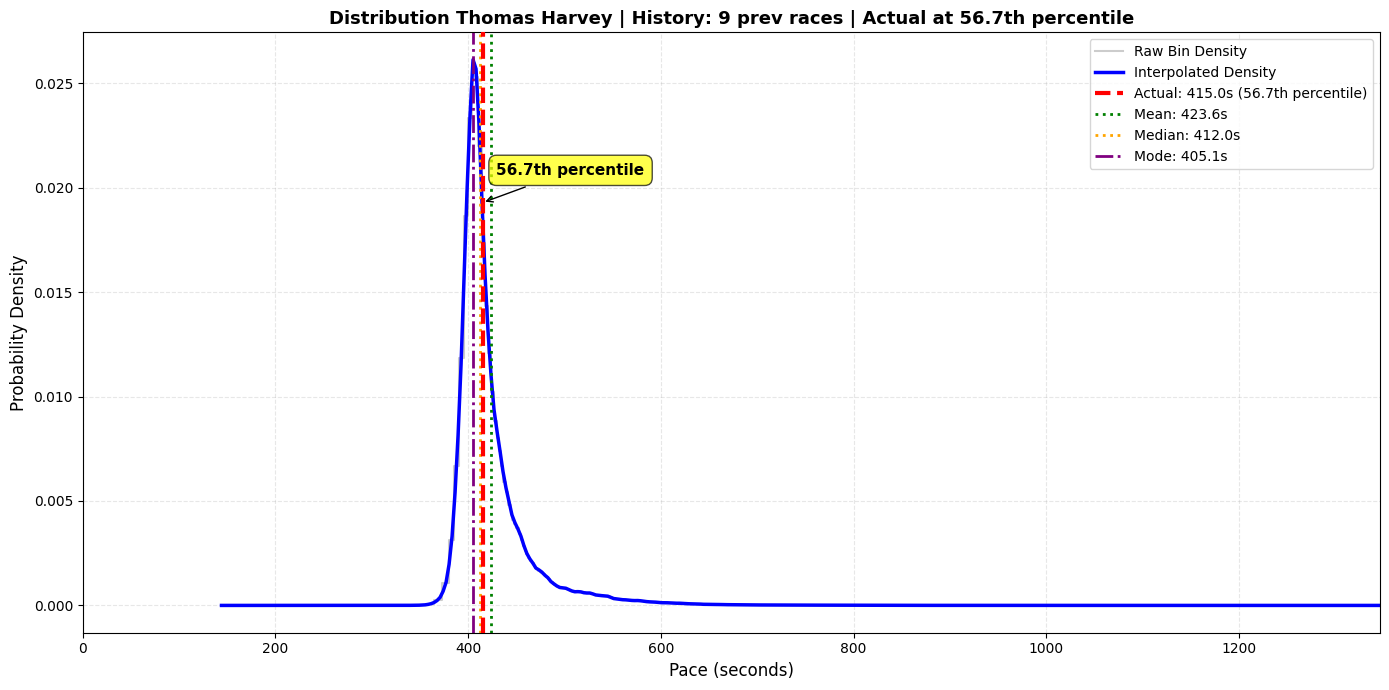

  Actual pace: 415.0s at 56.7th percentile

Plot 2/5: Jacquiline Kaddu


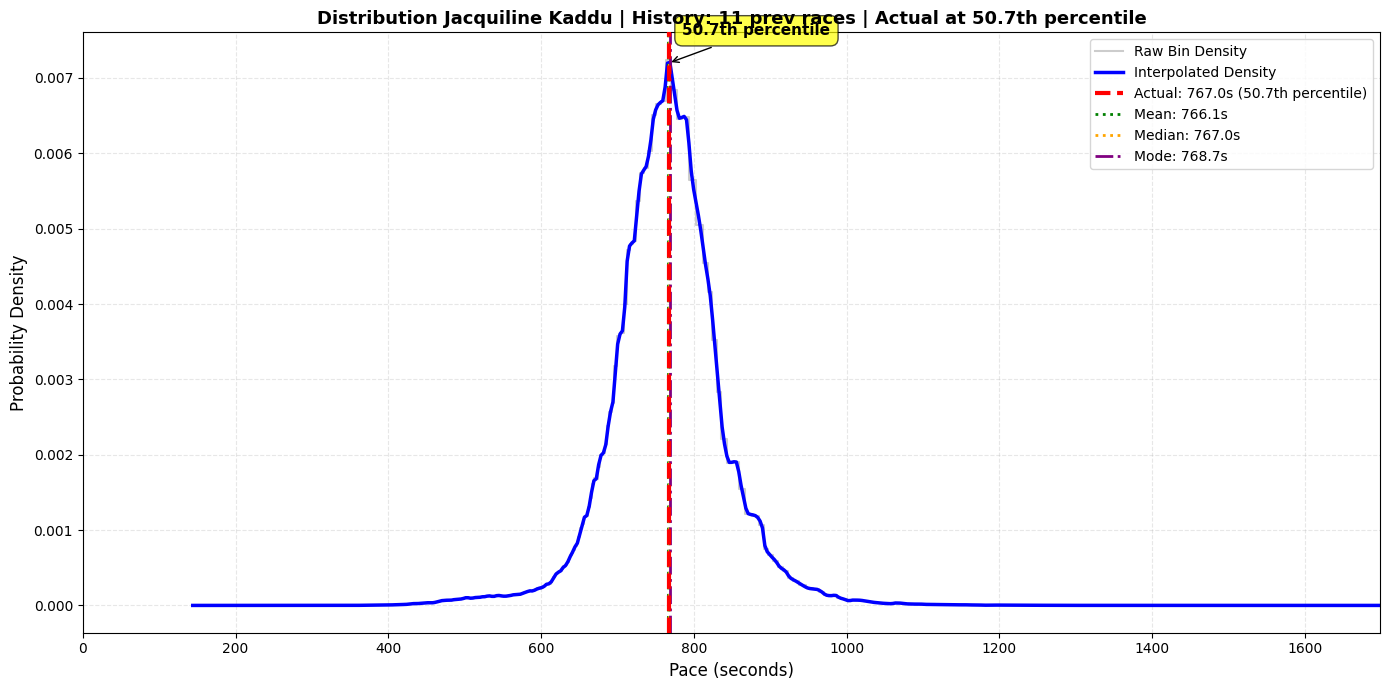

  Actual pace: 767.0s at 50.7th percentile

Plot 3/5: Katrina Pizarro


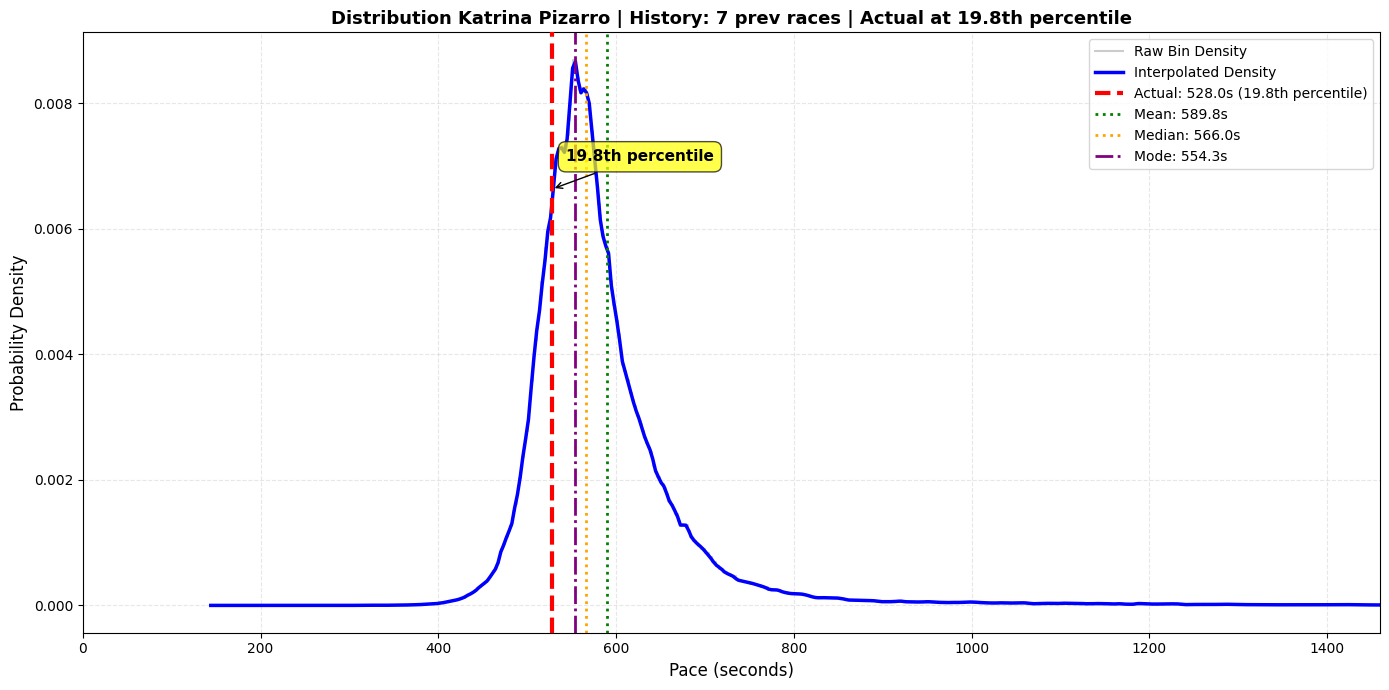

  Actual pace: 528.0s at 19.8th percentile

Plot 4/5: Sarah Degraaf


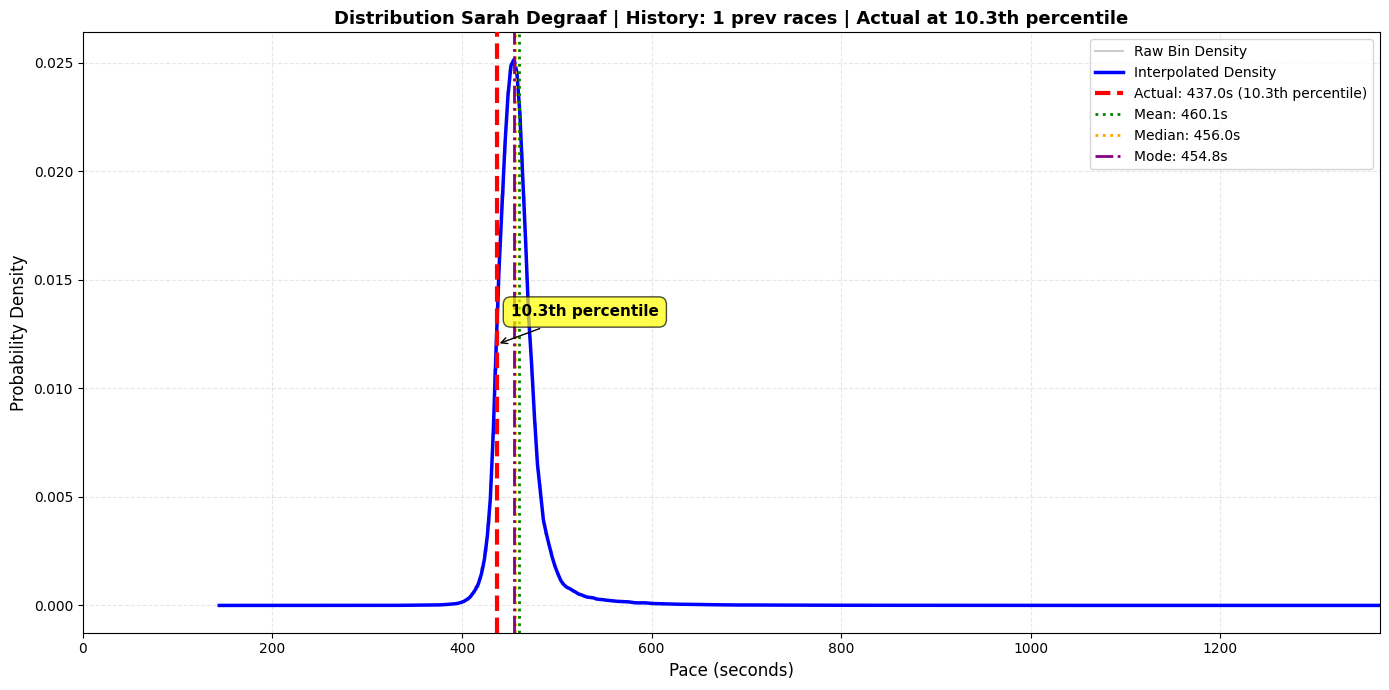

  Actual pace: 437.0s at 10.3th percentile

Plot 5/5: Frank Solano


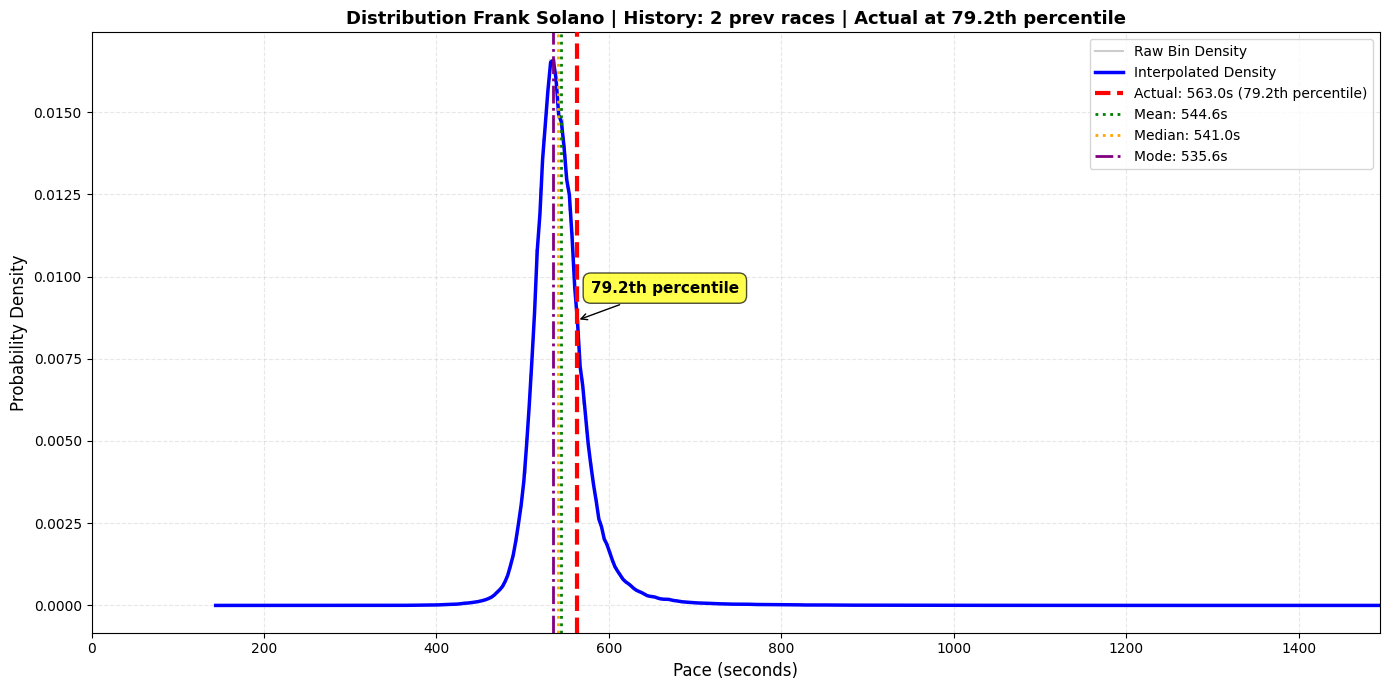

  Actual pace: 563.0s at 79.2th percentile



### Compute Percentiles for All Examples and Plot Histogram


In [27]:
# Compute percentiles for all examples (first 10,000)
print("Computing percentiles for examples...")
print()

# Check if inspection_runners is defined
if 'inspection_runners' not in globals() or len(inspection_runners) == 0:
    print("❌ ERROR: inspection_runners is not defined or empty.")
    print("   Please run the 'Load Runners Data' cell (Cell 7) first.")
    raise NameError("inspection_runners not defined. Run the data loading cell first.")

MAX_EXAMPLES = 10000
percentiles = []

total_examples = 0
for runner in inspection_runners:
    if not runner.training_examples:
        continue
    
    for ex in runner.training_examples:
        # Skip invalid examples
        if len(ex.unpadded_example_sequence) < 11:
            continue
        
        # Get prediction and compute quantile
        try:
            pred_result = predict_pace_distribution(ex)
            actual_pace = float(ex.actual_pace_seconds)
            percentile = compute_quantile(actual_pace, pred_result, pace_bins)
            percentiles.append(percentile)
            total_examples += 1
            
            if total_examples % 1000 == 0:
                print(f"  Processed {total_examples} examples...")
            
            if total_examples >= MAX_EXAMPLES:
                break
        except Exception as e:
            print(f"  Warning: Error processing example: {e}")
            continue
    
    if total_examples >= MAX_EXAMPLES:
        break

print(f"\n✅ Computed percentiles for {len(percentiles)} examples")
print(f"   Percentile range: {min(percentiles):.2f} to {max(percentiles):.2f}")
print(f"   Mean percentile: {np.mean(percentiles):.2f}")
print(f"   Median percentile: {np.median(percentiles):.2f}")
print()


Computing percentiles for examples...

  Processed 1000 examples...
  Processed 2000 examples...
  Processed 3000 examples...
  Processed 4000 examples...
  Processed 5000 examples...
  Processed 6000 examples...
  Processed 7000 examples...
  Processed 8000 examples...
  Processed 9000 examples...
  Processed 10000 examples...

✅ Computed percentiles for 10000 examples
   Percentile range: 0.00 to 100.00
   Mean percentile: 51.13
   Median percentile: 51.75



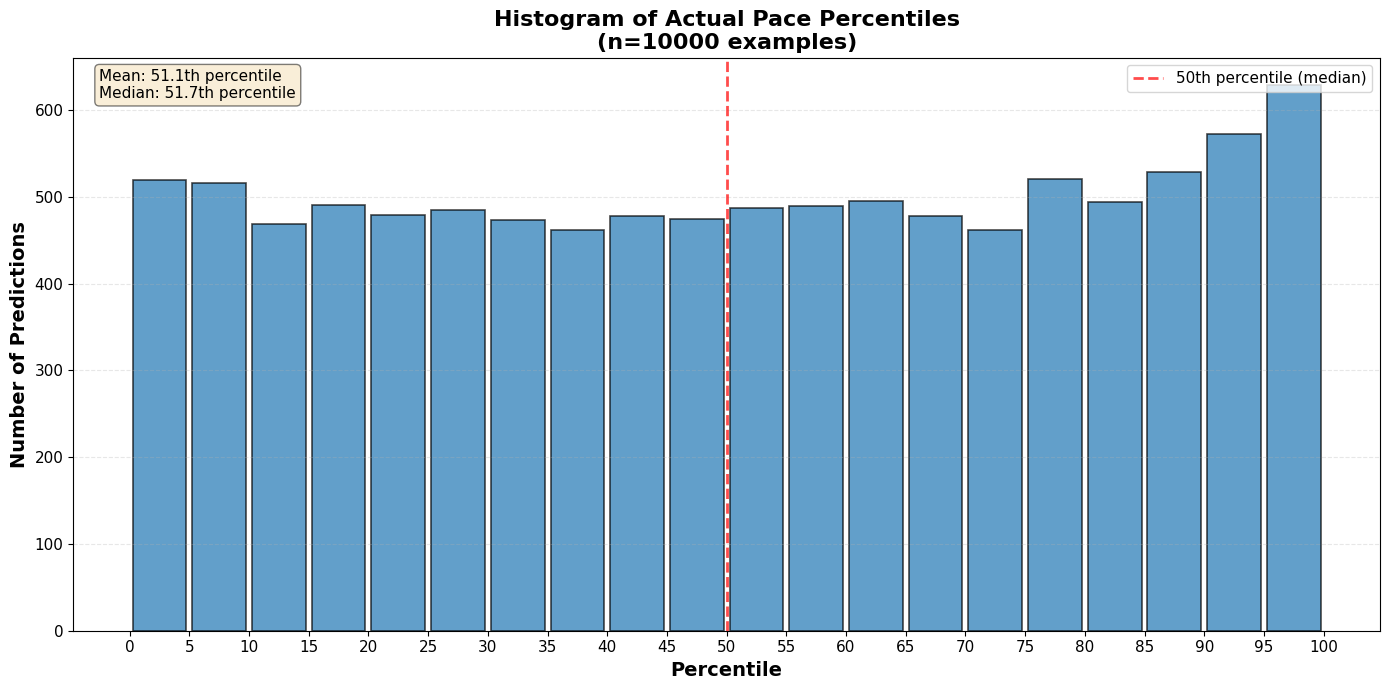

Histogram created with 20 bins (spacing 0.05)
Total predictions: 10000
Bin counts range: 462 to 629

CALIBRATION TEST (Kolmogorov-Smirnov)
Null hypothesis: Percentiles follow Uniform(0,1) distribution
KS statistic: 0.024979
P-value: 0.000007

❌ p-value < 0.05: Significantly non-uniform (model appears miscalibrated)



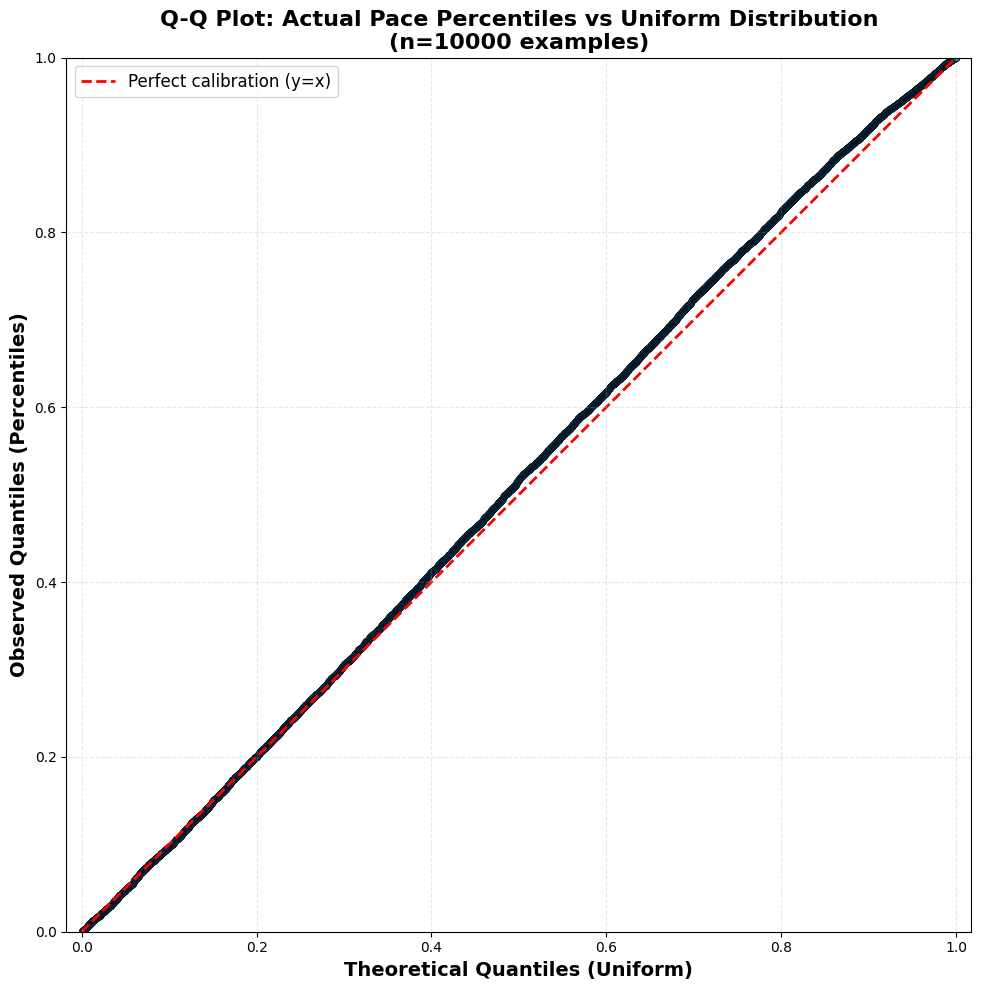

Q-Q Plot created.
If well-calibrated, points should fall along the red diagonal line (y=x).
Deviations indicate miscalibration:
  - Points above diagonal: model underestimates uncertainty
  - Points below diagonal: model overestimates uncertainty

CALIBRATION PLOT


  Processed 1000 examples...
  Processed 2000 examples...
  Processed 3000 examples...
  Processed 4000 examples...
  Processed 5000 examples...
  Processed 6000 examples...
  Processed 7000 examples...
  Processed 8000 examples...
  Processed 9000 examples...
  Processed 10000 examples...

✅ Collected 50000 data points from 10000 examples



ValueError: y_prob has values outside [0, 1].

In [38]:
# Plot histogram of percentiles
# X-axis: percentile (spacing 0.05, so bins are 0-0.05, 0.05-0.10, ..., 0.95-1.0)
# Y-axis: count of predictions in each bin

# Convert percentiles to fractions (0-1 range) for binning
percentiles_fraction = np.array(percentiles) / 100.0

# Create bins with spacing 0.05 (20 bins from 0 to 1.0)
bin_edges = np.arange(0, 1.05, 0.05)  # 0, 0.05, 0.10, ..., 1.0
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0  # Centers: 0.025, 0.075, ..., 0.975

# Compute histogram
counts, _ = np.histogram(percentiles_fraction, bins=bin_edges)

# Create the plot
plt.figure(figsize=(14, 7))
plt.bar(bin_centers * 100, counts, width=4.5, align='center', alpha=0.7, edgecolor='black', linewidth=1.2)
plt.xlabel('Percentile', fontsize=14, fontweight='bold')
plt.ylabel('Number of Predictions', fontsize=14, fontweight='bold')
plt.title(f'Histogram of Actual Pace Percentiles\n(n={len(percentiles)} examples)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.xticks(np.arange(0, 105, 5), fontsize=11)
plt.yticks(fontsize=11)

# Add vertical line at 50th percentile (median)
plt.axvline(50, color='red', linestyle='--', linewidth=2, alpha=0.7, label='50th percentile (median)')
plt.legend(fontsize=11)

# Add text annotation with summary stats
stats_text = f'Mean: {np.mean(percentiles):.1f}th percentile\nMedian: {np.median(percentiles):.1f}th percentile'
plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"Histogram created with {len(bin_edges)-1} bins (spacing 0.05)")
print(f"Total predictions: {len(percentiles)}")
print(f"Bin counts range: {counts.min()} to {counts.max()}")
print()

# Formal statistical test for calibration
from scipy.stats import kstest

# Convert percentiles to 0-1 range for the test
percentiles_fraction = np.array(percentiles) / 100.0

# If well-calibrated, percentiles should be Uniform(0,1)
statistic, pvalue = kstest(percentiles_fraction, 'uniform')

print("=" * 60)
print("CALIBRATION TEST (Kolmogorov-Smirnov)")
print("=" * 60)
print(f"Null hypothesis: Percentiles follow Uniform(0,1) distribution")
print(f"KS statistic: {statistic:.6f}")
print(f"P-value: {pvalue:.6f}")
print()
if pvalue > 0.05:
    print("✅ p-value > 0.05: Cannot reject uniformity (model appears well-calibrated)")
else:
    print("❌ p-value < 0.05: Significantly non-uniform (model appears miscalibrated)")
print("=" * 60)
print()

# Quantile-Quantile (Q-Q) plot
# Compare observed percentiles against uniform distribution
from scipy.stats import probplot

# Sort percentiles for Q-Q plot
sorted_percentiles = np.sort(percentiles_fraction)

# Theoretical quantiles from uniform distribution
n = len(sorted_percentiles)
theoretical_quantiles = np.linspace(0, 1, n)

# Create Q-Q plot
plt.figure(figsize=(10, 10))
plt.scatter(theoretical_quantiles, sorted_percentiles, alpha=0.5, s=20, edgecolors='black', linewidths=0.5)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect calibration (y=x)', zorder=1)
plt.xlabel('Theoretical Quantiles (Uniform)', fontsize=14, fontweight='bold')
plt.ylabel('Observed Quantiles (Percentiles)', fontsize=14, fontweight='bold')
plt.title(f'Q-Q Plot: Actual Pace Percentiles vs Uniform Distribution\n(n={len(percentiles)} examples)', 
          fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12)
plt.axis('equal')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Q-Q Plot created.")
print("If well-calibrated, points should fall along the red diagonal line (y=x).")
print("Deviations indicate miscalibration:")
print("  - Points above diagonal: model underestimates uncertainty")
print("  - Points below diagonal: model overestimates uncertainty")
print()

# Calibration Plot: Predicted vs Observed Frequencies
print("=" * 60)
print("CALIBRATION PLOT")
print("=" * 60)
print()

from sklearn.calibration import calibration_curve

# Collect predicted probabilities and actual outcomes
predicted_probs = []
actual_outcomes = []

print("Collecting calibration data from examples...")
print()

# Use the examples we already processed (limit to first 10,000 to match cell 15)
MAX_EXAMPLES_FOR_CALIBRATION = 10000
total_examples = 0

for runner in inspection_runners:
    if not runner.training_examples:
        continue
    
    for ex in runner.training_examples:
        if len(ex.unpadded_example_sequence) < 11:
            continue
        
        if total_examples >= MAX_EXAMPLES_FOR_CALIBRATION:
            break
        
        try:
            pred_result = predict_pace_distribution(ex)
            actual_pace = float(ex.actual_pace_seconds)
            
            # Sample multiple random thresholds for each example
            n_samples_per_example = 5
            for _ in range(n_samples_per_example):
                # Pick a random threshold bin
                threshold_bin = np.random.randint(0, len(pace_bins))
                
                # Predicted probability of pace being <= threshold (CDF)
                p_probs = pred_result['probs']
                p_probs_normalized = p_probs / p_probs.sum() if p_probs.sum() > 0 else p_probs
                cdf_at_threshold = np.cumsum(p_probs_normalized)[threshold_bin]
                
                pred_prob = cdf_at_threshold
                
                # Actual outcome: did actual pace <= threshold?
                bin_ends = np.array([b['end'] for b in pace_bins])
                threshold_value = bin_ends[threshold_bin]
                actual = 1 if actual_pace <= threshold_value else 0
                
                predicted_probs.append(pred_prob)
                actual_outcomes.append(actual)
            
            total_examples += 1
            if total_examples % 1000 == 0:
                print(f"  Processed {total_examples} examples...")
                
        except Exception as e:
            continue
    
    if total_examples >= MAX_EXAMPLES_FOR_CALIBRATION:
        break

print(f"\n✅ Collected {len(predicted_probs)} data points from {total_examples} examples")
print()

# Check if we have data
if len(predicted_probs) == 0 or len(actual_outcomes) == 0:
    print("❌ ERROR: No calibration data collected. Cannot create calibration plot.")
    print("   This may be due to MPS device issues. Try setting PYTORCH_ENABLE_MPS_FALLBACK=1")
else:
    # Ensure we have both 0 and 1 in actual_outcomes
    unique_outcomes = np.unique(actual_outcomes)
    if len(unique_outcomes) < 2:
        print(f"⚠️  Warning: Only found {unique_outcomes} in outcomes. Need both 0 and 1.")
        print("   This means all predictions had the same outcome. Cannot create calibration curve.")
    else:
        # Create calibration curve
        fraction_of_positives, mean_predicted_value = calibration_curve(
            actual_outcomes, predicted_probs, n_bins=10, strategy='uniform', pos_label=1
        )

# Plot calibration curve
plt.figure(figsize=(10, 8))
plt.plot(mean_predicted_value, fraction_of_positives, 's-', markersize=10, linewidth=2, 
         label='Model Calibration', color='blue')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability', fontsize=14, fontweight='bold')
plt.ylabel('Observed Frequency', fontsize=14, fontweight='bold')
plt.title('Calibration Plot: Predicted vs Observed Frequencies\n' + 
          f'(n={len(predicted_probs)} predictions)', 
          fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Print summary statistics
print("Calibration Summary:")
print(f"  Total predictions: {len(predicted_probs)}")
print(f"  Mean predicted probability: {np.mean(predicted_probs):.3f}")
print(f"  Mean observed frequency: {np.mean(actual_outcomes):.3f}")
print()
print("Interpretation:")
print("  - Points on the diagonal (dashed line) = perfect calibration")
print("  - Points above diagonal = model overconfident (predicts too high)")
print("  - Points below diagonal = model underconfident (predicts too low)")


Before clipping:
  predicted_probs min: 0.0000000644
  predicted_probs max: 1.0000008345
  predicted_probs mean: 0.600640

⚠️  Warning: Clipped 0 values below 0 and 81 values above 1



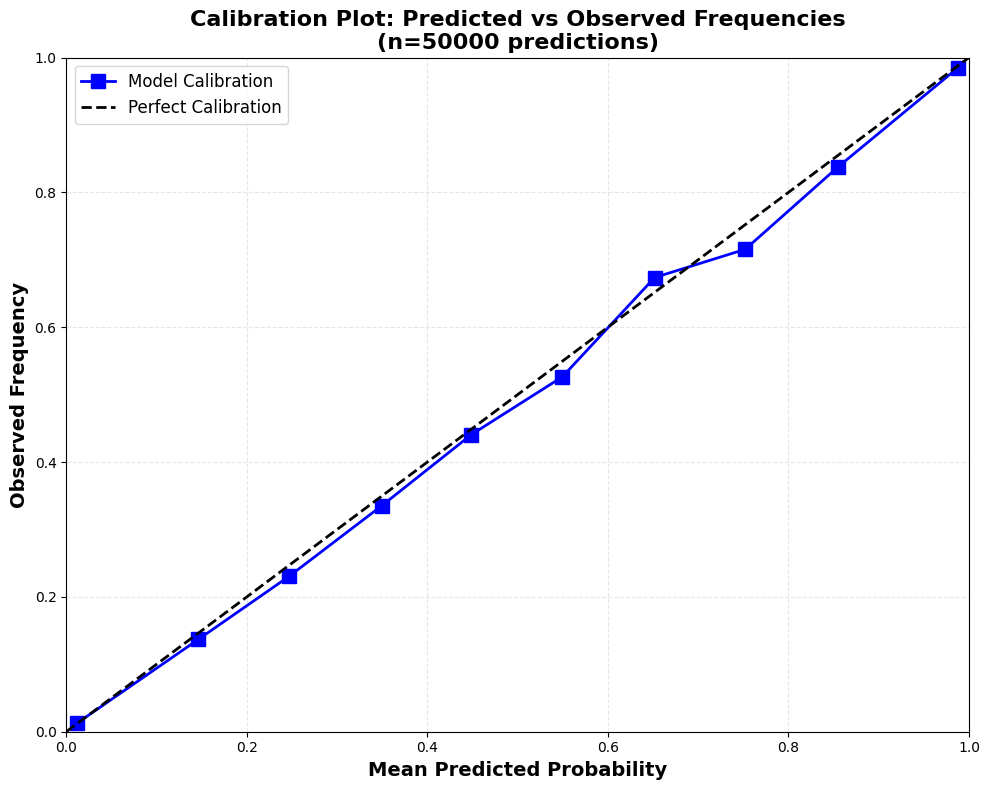

Calibration Summary:
  Total predictions: 50000
  Mean predicted probability: 0.601
  Mean observed frequency: 0.597

Interpretation:
  - Points on the diagonal (dashed line) = perfect calibration
  - Points above diagonal = model overconfident (predicts too high)
  - Points below diagonal = model underconfident (predicts too low)


In [39]:
# Fix calibration data: clip predicted_probs to [0, 1] and create calibration curve
# This cell fixes the ValueError from Cell 16 by ensuring all probabilities are in valid range

from sklearn.calibration import calibration_curve

# Check if calibration data exists from previous cell
if 'predicted_probs' not in globals() or 'actual_outcomes' not in globals():
    print("❌ ERROR: predicted_probs or actual_outcomes not found.")
    print("   Please run Cell 16 first to collect calibration data.")
else:
    # Convert to numpy arrays for easier manipulation
    predicted_probs_array = np.array(predicted_probs)
    actual_outcomes_array = np.array(actual_outcomes)
    
    # Check current range
    print(f"Before clipping:")
    print(f"  predicted_probs min: {predicted_probs_array.min():.10f}")
    print(f"  predicted_probs max: {predicted_probs_array.max():.10f}")
    print(f"  predicted_probs mean: {predicted_probs_array.mean():.6f}")
    print()
    
    # Clip values to [0, 1] to fix the ValueError
    predicted_probs_clipped = np.clip(predicted_probs_array, 0.0, 1.0)
    
    # Check how many values were clipped
    n_clipped_low = np.sum(predicted_probs_array < 0)
    n_clipped_high = np.sum(predicted_probs_array > 1)
    
    if n_clipped_low > 0 or n_clipped_high > 0:
        print(f"⚠️  Warning: Clipped {n_clipped_low} values below 0 and {n_clipped_high} values above 1")
    else:
        print("✅ All values already in [0, 1] range")
    print()
    
    # Ensure we have both 0 and 1 in actual_outcomes
    unique_outcomes = np.unique(actual_outcomes_array)
    if len(unique_outcomes) < 2:
        print(f"⚠️  Warning: Only found {unique_outcomes} in outcomes. Need both 0 and 1.")
        print("   This means all predictions had the same outcome. Cannot create calibration curve.")
    else:
        # Create calibration curve with clipped probabilities
        fraction_of_positives, mean_predicted_value = calibration_curve(
            actual_outcomes_array, predicted_probs_clipped, n_bins=10, strategy='uniform', pos_label=1
        )
        
        # Plot calibration curve
        plt.figure(figsize=(10, 8))
        plt.plot(mean_predicted_value, fraction_of_positives, 's-', markersize=10, linewidth=2, 
                 label='Model Calibration', color='blue')
        plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
        plt.xlabel('Mean Predicted Probability', fontsize=14, fontweight='bold')
        plt.ylabel('Observed Frequency', fontsize=14, fontweight='bold')
        plt.title('Calibration Plot: Predicted vs Observed Frequencies\n' + 
                  f'(n={len(predicted_probs_clipped)} predictions)', 
                  fontsize=16, fontweight='bold')
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print("Calibration Summary:")
        print(f"  Total predictions: {len(predicted_probs_clipped)}")
        print(f"  Mean predicted probability: {predicted_probs_clipped.mean():.3f}")
        print(f"  Mean observed frequency: {actual_outcomes_array.mean():.3f}")
        print()
        print("Interpretation:")
        print("  - Points on the diagonal (dashed line) = perfect calibration")
        print("  - Points above diagonal = model overconfident (predicts too high)")
        print("  - Points below diagonal = model underconfident (predicts too low)")
